# SegTHOR preprocessing options: visual check

Compares several preprocessing runs of `slice_segthor.py` side by side, using the 2D PNG slices.
Nothing here modifies the data.

Before running: slice the data once per option, each into its own folder under `data/prep_options/`
(commands below).

Sections
1. Inventory: patients, slices, image size, voxel spacing per option (same patients/slices for all options; resampled option has constant `dx`)
2. Label sanity and cropping: no invalid GT values (check for organs cut at the border)
3. Intensity distributions: how many grey levels each organ gets (contrast)
4. Same slices, all options side by side (with GT contours)
5. Zoomed detail: sharpness and noise around the organs
6. Patient gallery: one slice per patient for a chosen option
7. Normalization statistics each option would give (mean/std for z-scoring)

### Commands used to create the folders (PowerShell, from the repo root)

```powershell
python slice_segthor.py --source_dir data --dest_dir data/prep_options/baseline     --retains 10 --fold 0 -p 4
python slice_segthor.py --source_dir data --dest_dir data/prep_options/percentile   --retains 10 --fold 0 -p 4 --intensity_mode percentile
python slice_segthor.py --source_dir data --dest_dir data/prep_options/hu_wide      --retains 10 --fold 0 -p 4 --intensity_mode fixed_hu --hu_min -1000 --hu_max 400
python slice_segthor.py --source_dir data --dest_dir data/prep_options/hu_mid       --retains 10 --fold 0 -p 4 --intensity_mode fixed_hu --hu_min -250 --hu_max 350
python slice_segthor.py --source_dir data --dest_dir data/prep_options/hu_soft      --retains 10 --fold 0 -p 4 --intensity_mode fixed_hu --hu_min -160 --hu_max 240
python slice_segthor.py --source_dir data --dest_dir data/prep_options/hu_soft_rs18 --retains 10 --fold 0 -p 4 --intensity_mode fixed_hu --hu_min -160 --hu_max 240 --target_spacing 1.8
```

## 0. Settings

In [ ]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from PIL import Image


#global settings 
DATA_ROOT = Path("data/prep_options")

OPTIONS = {
    "baseline (min-max)": "baseline",
    "percentile 1-99": "percentile",
    "HU -1000/400": "hu_wide",
    "HU -250/350": "hu_mid",
    "HU -160/240": "hu_soft",
    "HU -160/240 + 1.8 mm": "hu_soft_rs18",
}

SPLIT = "train" 
MAX_SLICES = None  
SEED = 0

LABEL_NAMES = {0: "background", 1: "esophagus", 2: "heart", 3: "trachea", 4: "aorta"}
LABEL_COLORS = {1: "#00D7D7", 2: "#FF4D4D", 3: "#59D65F", 4: "#E44DE1"}
GT_SCALE = 63                      # slice_segthor.py stores label k as k * 63
VALID_GT_VALUES = {0, 63, 126, 189, 252}

paths = {name: DATA_ROOT / folder for name, folder in OPTIONS.items()}
missing = [f"{name}  ({p})" for name, p in paths.items() if not p.exists()]
paths = {name: p for name, p in paths.items() if p.exists()}

if missing:
    print("Skipped (folder not found):", *missing, sep="\n  ")
assert paths, f"No option folders found in {DATA_ROOT.resolve()}"
print("Comparing:", *paths, sep="\n  ")

Comparing:
  baseline (min-max)
  percentile 1-99
  HU -1000/400
  HU -250/350
  HU -160/240
  HU -160/240 + 1.8 mm


## Helper functions

In [2]:
NAME_RE = re.compile(r"^(?P<patient>.+)_(?P<z>\d{4})\.png$")


def index_slices(split_dir: Path) -> pd.DataFrame:
    """One row per slice PNG: patient id, slice index, file name."""
    rows = []
    for f in sorted((split_dir / "img").glob("*.png")):
        m = NAME_RE.match(f.name)
        if m:
            rows.append({"patient": m["patient"], "z": int(m["z"]), "file": f.name})
    return pd.DataFrame(rows, columns=["patient", "z", "file"])


def load_png(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    return arr[..., 0] if arr.ndim == 3 else arr


def load_pair(root: Path, split: str, fname: str) -> tuple[np.ndarray, np.ndarray]:
    img = load_png(root / split / "img" / fname)
    gt = load_png(root / split / "gt" / fname) // GT_SCALE
    return img, gt


def hist_stats(h: np.ndarray) -> dict:
    """Mean, std and percentiles from a 256-bin grey-level histogram."""
    n = h.sum()
    if n == 0:
        return {"mean": np.nan, "std": np.nan, "p1": np.nan, "p50": np.nan, "p99": np.nan}
    v = np.arange(256)
    mean = (v * h).sum() / n
    std = np.sqrt(((v - mean) ** 2 * h).sum() / n)
    cdf = np.cumsum(h) / n
    p1, p50, p99 = (int(np.searchsorted(cdf, q)) for q in (0.01, 0.5, 0.99))
    return {"mean": mean, "std": std, "p1": p1, "p50": p50, "p99": p99}


def show(ax, img, gt=None, title=None, contours=True):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    if contours and gt is not None:
        for label, color in LABEL_COLORS.items():
            if (gt == label).any():
                ax.contour(gt == label, levels=[0.5], colors=color, linewidths=0.8)
    if title:
        ax.set_title(title, fontsize=9)
    ax.axis("off")


LEGEND = [Patch(color=c, label=LABEL_NAMES[k]) for k, c in LABEL_COLORS.items()]

## 1. Inventory

Every option should have the same patients and the same number of slices 

In [3]:
rows, val_sets = [], {}
for name, root in paths.items():
    row = {"option": name}
    for split in ("train", "val"):
        df = index_slices(root / split)
        row[f"{split} patients"] = df["patient"].nunique()
        row[f"{split} slices"] = len(df)
        if split == "val":
            val_sets[name] = frozenset(df["patient"])
    first = next((root / SPLIT / "img").glob("*.png"), None)
    if first is not None:
        im = load_png(first)
        row["image size"] = f"{im.shape[0]}x{im.shape[1]}"
    sp_file = root / "spacing.pkl"
    if sp_file.exists():
        with sp_file.open("rb") as fh:
            spacing = pickle.load(fh)
        dx = np.array([float(v[0]) for v in spacing.values()])
        dz = np.array([float(v[2]) for v in spacing.values()])
        row["dx mm (min-max)"] = f"{dx.min():.2f} - {dx.max():.2f}"
        row["dz mm (min-max)"] = f"{dz.min():.2f} - {dz.max():.2f}"
    rows.append(row)

display(pd.DataFrame(rows).set_index("option"))

if len(set(val_sets.values())) > 1:
    print("WARNING: the validation patients differ between options -> rerun with the same --retains/--fold/--seed.")
else:
    print("OK: all options use the same validation patients.")

,train patients,train slices,val patients,val slices,image size,dx mm (min-max),dz mm (min-max)
option,,,,,,,
baseline (min-max),30,5453,10,1967,256x256,0.90 - 1.37,2.00 - 2.50
percentile 1-99,30,5453,10,1967,256x256,0.90 - 1.37,2.00 - 2.50
HU -1000/400,30,5453,10,1967,256x256,0.90 - 1.37,2.00 - 2.50
HU -250/350,30,5453,10,1967,256x256,0.90 - 1.37,2.00 - 2.50
HU -160/240,30,5453,10,1967,256x256,0.90 - 1.37,2.00 - 2.50
HU -160/240 + 1.8 mm,30,5453,10,1967,256x256,1.80 - 1.80,2.00 - 2.50


OK: all options use the same validation patients.


## 2. Label sanity and cropping

Check that GT PNGs only contain the 5 valid values, count class pixels, and count slices where an organ touches the image border: with resampling + crop that means the organ was cut off. 

In [4]:
def scan_option(root: Path, split: str = SPLIT, max_slices=MAX_SLICES) -> dict:
    df = index_slices(root / split)
    if max_slices and len(df) > max_slices:
        df = df.sample(max_slices, random_state=SEED).sort_values(["patient", "z"])
    hist_all = np.zeros(256, np.int64)
    hist_lab = np.zeros((5, 256), np.int64)
    border = np.zeros(5, np.int64)
    bad_values: set = set()
    areas = np.zeros((len(df), 5), np.int64)

    for i, fname in enumerate(df["file"]):
        img = load_png(root / split / "img" / fname)
        gt_raw = load_png(root / split / "gt" / fname)
        bad_values |= set(np.unique(gt_raw).tolist()) - VALID_GT_VALUES
        gt = gt_raw // GT_SCALE

        hist_all += np.bincount(img.ravel(), minlength=256)
        areas[i] = np.bincount(gt.ravel(), minlength=5)[:5]
        for label in range(5):
            mask = gt == label
            if mask.any():
                hist_lab[label] += np.bincount(img[mask], minlength=256)
                if label and (mask[0].any() or mask[-1].any() or mask[:, 0].any() or mask[:, -1].any()):
                    border[label] += 1

    df = df.reset_index(drop=True)
    for label in range(5):
        df[LABEL_NAMES[label]] = areas[:, label]
    return {"df": df, "hist_all": hist_all, "hist_lab": hist_lab, "border": border, "bad_values": bad_values}


scans = {}
for name, root in paths.items():
    print(f"Scanning {name} ...", end=" ", flush=True)
    scans[name] = scan_option(root)
    print(f"{len(scans[name]['df'])} slices")

rows = []
for name, s in scans.items():
    total = s["hist_lab"].sum()
    row = {"option": name, "invalid GT values": sorted(s["bad_values"]) or "none"}
    for label in range(1, 5):
        row[f"% px {LABEL_NAMES[label]}"] = 100 * s["hist_lab"][label].sum() / total
    for label in range(1, 5):
        row[f"cut at border: {LABEL_NAMES[label]}"] = int(s["border"][label])
    rows.append(row)

display(pd.DataFrame(rows).set_index("option").round(3))

Scanning baseline (min-max) ... 5453 slices
Scanning percentile 1-99 ... 5453 slices
Scanning HU -1000/400 ... 5453 slices
Scanning HU -250/350 ... 5453 slices
Scanning HU -160/240 ... 5453 slices
Scanning HU -160/240 + 1.8 mm ... 5453 slices


,invalid GT values,% px esophagus,% px heart,% px trachea,% px aorta,cut at border: esophagus,cut at border: heart,cut at border: trachea,cut at border: aorta
option,,,,,,,,,
baseline (min-max),none,0.048,0.773,0.035,0.202,0,0,0,0
percentile 1-99,none,0.048,0.773,0.035,0.202,0,0,0,0
HU -1000/400,none,0.048,0.773,0.035,0.202,0,0,0,0
HU -250/350,none,0.048,0.773,0.035,0.202,0,0,0,0
HU -160/240,none,0.048,0.773,0.035,0.202,0,0,0,0
HU -160/240 + 1.8 mm,none,0.058,0.934,0.042,0.241,0,0,0,0


## 3. Intensity distributions

Left: grey-level histogram of all pixels (log scale). 
Right: distribution of grey levels inside each organ.

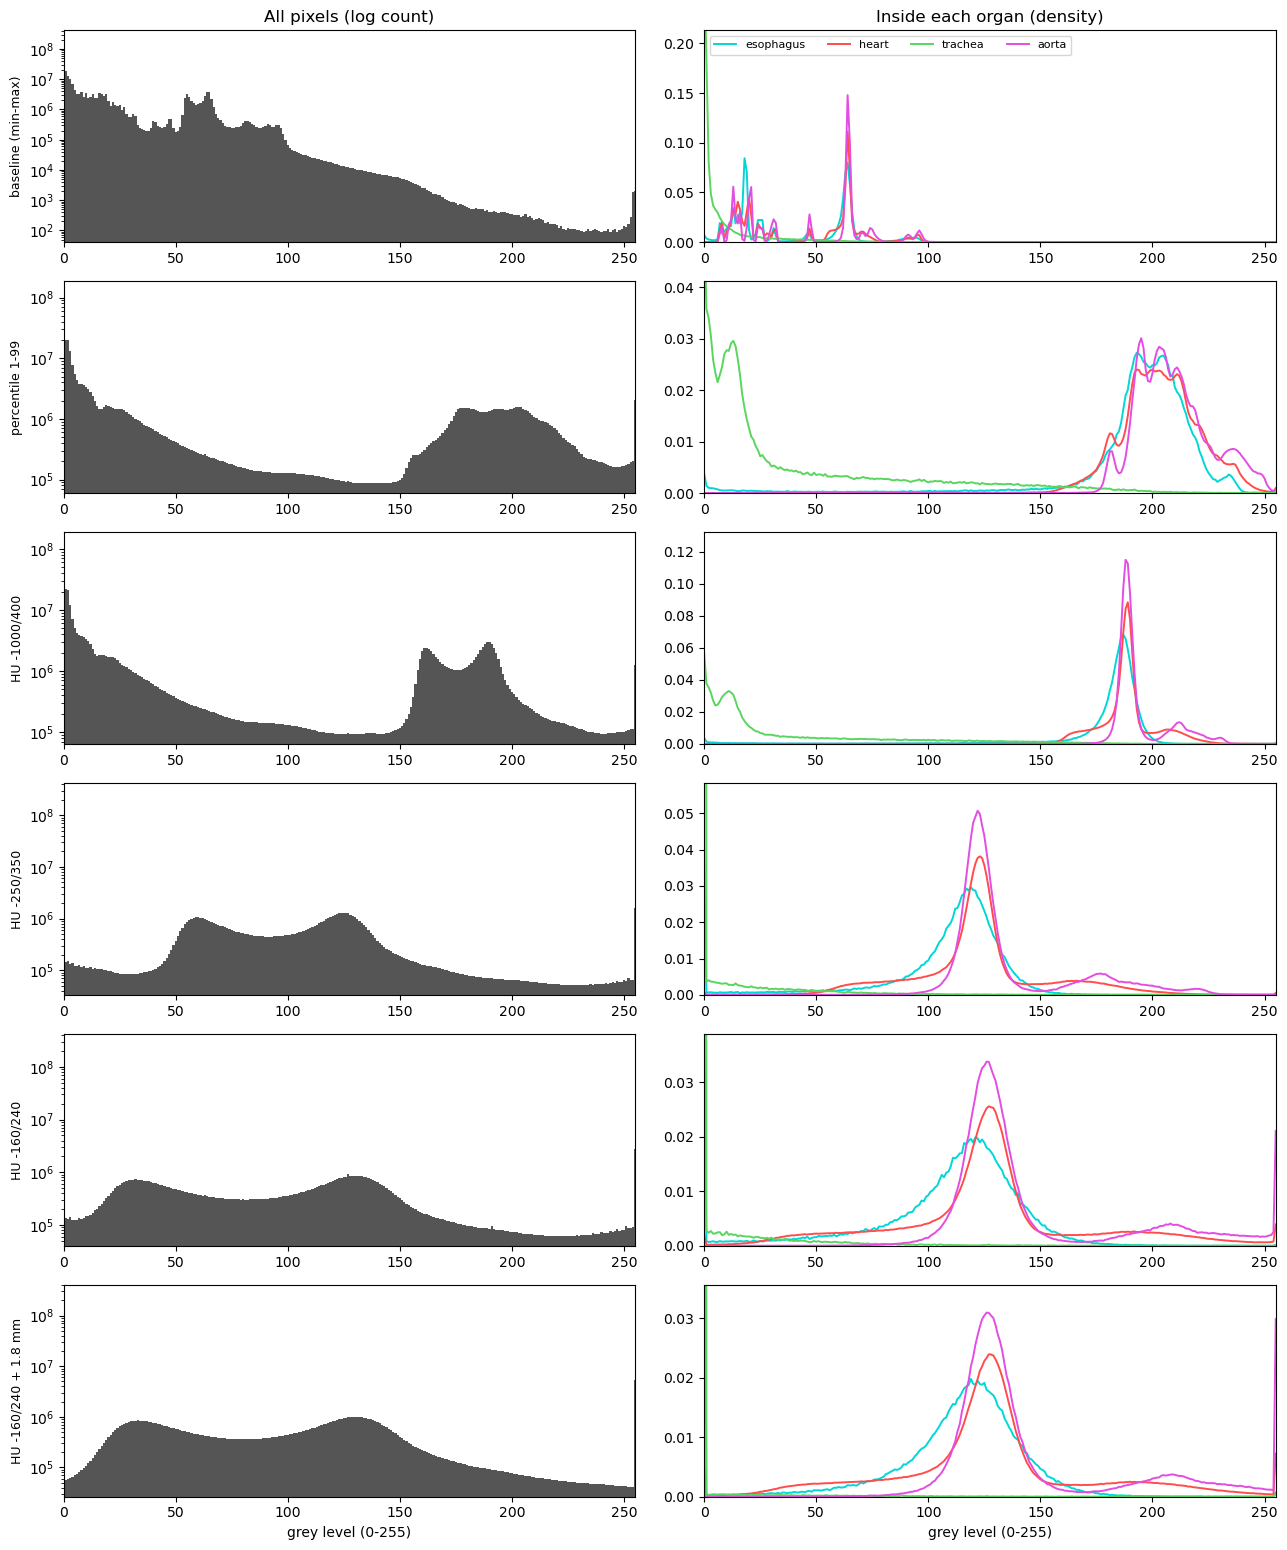

grey levels used by 98% of organ pixels,esophagus,heart,trachea,aorta
option,,,,
baseline (min-max),94,89,64,89
percentile 1-99,228,79,187,69
HU -1000/400,194,65,173,51
HU -250/350,151,151,90,119
HU -160/240,169,222,89,160
HU -160/240 + 1.8 mm,172,227,59,162


mean grey level per organ,esophagus,heart,trachea,aorta
option,,,,
baseline (min-max),39.7,43.3,8.1,46.7
percentile 1-99,192.2,203.6,40.1,209.2
HU -1000/400,177.2,188.6,37.0,194.2
HU -250/350,106.3,122.6,5.1,135.5
HU -160/240,106.4,127.0,4.1,145.8
HU -160/240 + 1.8 mm,107.1,126.8,1.6,146.0


In [5]:
n = len(scans)
fig, axes = plt.subplots(n, 2, figsize=(13, 2.6 * n), squeeze=False)
grey = np.arange(256)
for (name, s), (ax_all, ax_org) in zip(scans.items(), axes):
    ax_all.bar(grey, s["hist_all"], width=1.0, color="#555555")
    ax_all.set_yscale("log")
    ax_all.set_xlim(0, 255)
    ax_all.set_ylabel(name, fontsize=9)
    ymax = 0.0
    for label, color in LABEL_COLORS.items():
        h = s["hist_lab"][label]
        if h.sum():
            dens = h / h.sum()
            ax_org.plot(grey, dens, color=color, lw=1.4, label=LABEL_NAMES[label])
            ymax = max(ymax, dens[1:255].max())
    ax_org.set_xlim(0, 255)
    ax_org.set_ylim(0, ymax * 1.15 or 1)  # ignore spikes at 0/255 (clipped values) when scaling
axes[0, 0].set_title("All pixels (log count)")
axes[0, 1].set_title("Inside each organ (density)")
axes[-1, 0].set_xlabel("grey level (0-255)")
axes[-1, 1].set_xlabel("grey level (0-255)")
axes[0, 1].legend(fontsize=8, ncol=4, loc="upper left")
fig.tight_layout()
plt.show()

rows = []
for name, s in scans.items():
    for label in range(1, 5):
        st = hist_stats(s["hist_lab"][label])
        rows.append({"option": name, "organ": LABEL_NAMES[label], "mean": st["mean"], "std": st["std"],
                     "p1": st["p1"], "p99": st["p99"], "grey levels used (p99-p1)": st["p99"] - st["p1"]})
organ_table = pd.DataFrame(rows)
order = list(scans)
organs = [LABEL_NAMES[k] for k in range(1, 5)]
display(organ_table.pivot(index="option", columns="organ", values="grey levels used (p99-p1)")
        .reindex(index=order, columns=organs).rename_axis(columns="grey levels used by 98% of organ pixels"))
display(organ_table.pivot(index="option", columns="organ", values="mean").round(1)
        .reindex(index=order, columns=organs).rename_axis(columns="mean grey level per organ"))

## 4. Same slices, all options side by side

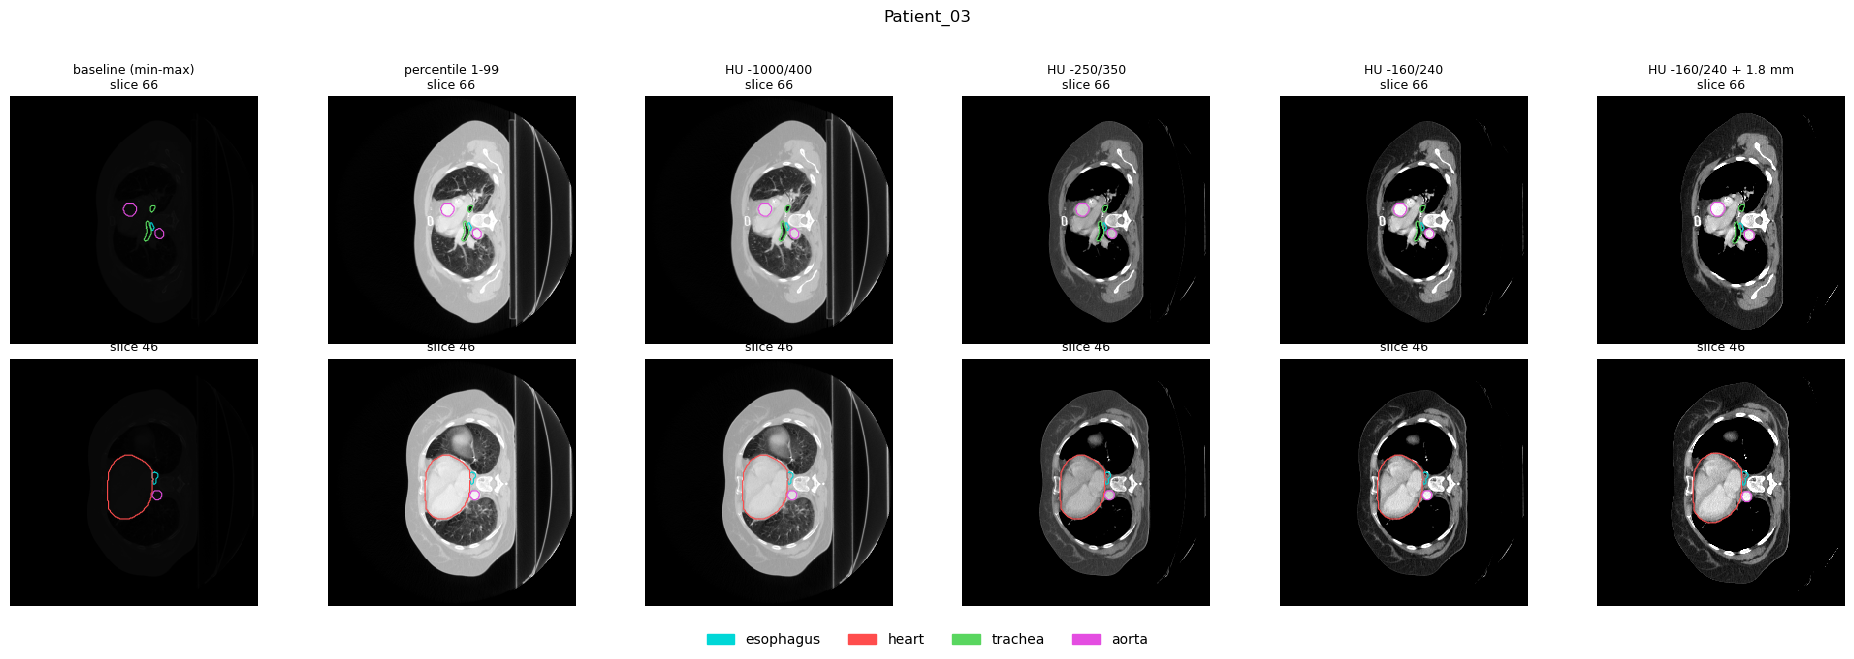

In [ ]:
PATIENT = None  
SLICES = None   

ref = scans[next(iter(scans))]["df"]
patient = PATIENT or sorted(ref["patient"].unique())[0]
pdf = ref[ref["patient"] == patient]
if SLICES is None:
    fg = pdf[[LABEL_NAMES[k] for k in range(1, 5)]].sum(axis=1)
    picks = [pdf.loc[pdf["trachea"].idxmax(), "z"], pdf.loc[pdf["heart"].idxmax(), "z"], pdf.loc[fg.idxmax(), "z"]]
    slices = list(dict.fromkeys(int(z) for z in picks))
else:
    slices = list(SLICES)

fig, axes = plt.subplots(len(slices), len(paths), figsize=(3.2 * len(paths), 3.3 * len(slices)), squeeze=False)
for r, z in enumerate(slices):
    fname = f"{patient}_{z:04d}.png"
    for c, (name, root) in enumerate(paths.items()):
        ax = axes[r, c]
        if not (root / SPLIT / "img" / fname).exists():
            ax.set_title(f"{name}\n(missing)", fontsize=9)
            ax.axis("off")
            continue
        img, gt = load_pair(root, SPLIT, fname)
        show(ax, img, gt, title=f"{name}\nslice {z}" if r == 0 else f"slice {z}")
fig.legend(handles=LEGEND, loc="lower center", ncol=4, frameon=False)
fig.suptitle(patient, fontsize=12)
height = fig.get_figheight()
fig.tight_layout(rect=(0, 0.35 / height, 1, 1 - 0.3 / height))
plt.show()

## 5. Zoomed detail around the organs

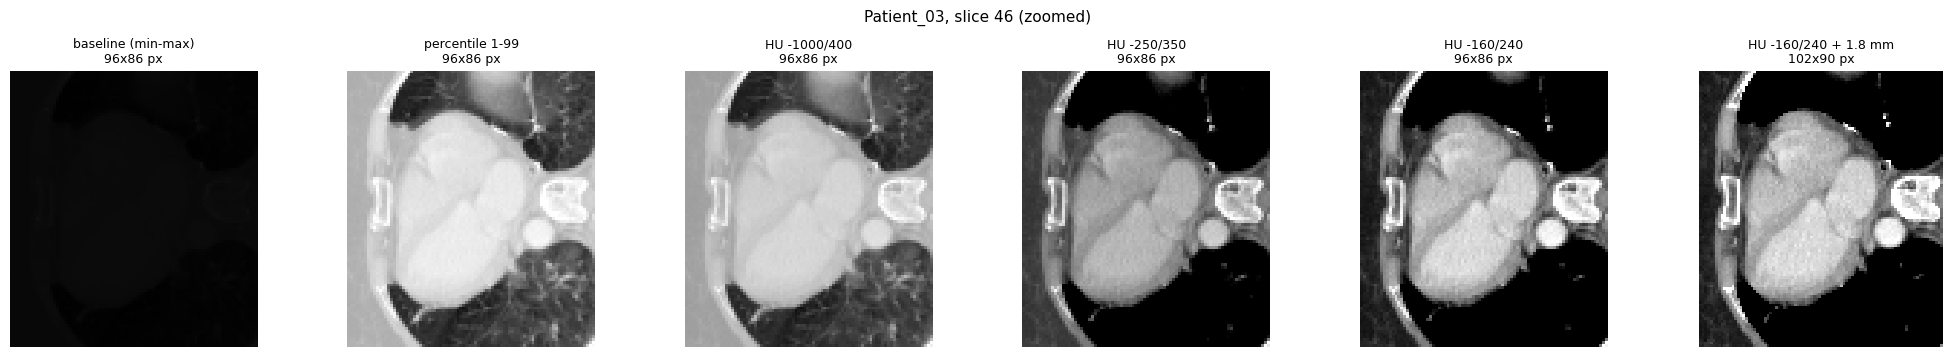

In [ ]:
ZOOM_SLICE = None  
MARGIN = 15        

z = ZOOM_SLICE if ZOOM_SLICE is not None else (slices[1] if len(slices) > 1 else slices[0])
fname = f"{patient}_{z:04d}.png"
fig, axes = plt.subplots(1, len(paths), figsize=(3.4 * len(paths), 3.6), squeeze=False)
for ax, (name, root) in zip(axes[0], paths.items()):
    if not (root / SPLIT / "img" / fname).exists():
        ax.axis("off")
        continue
    img, gt = load_pair(root, SPLIT, fname)
    ys, xs = np.nonzero(gt)
    if len(ys) == 0:
        crop = img
    else:
        y0, y1 = max(ys.min() - MARGIN, 0), min(ys.max() + MARGIN + 1, img.shape[0])
        x0, x1 = max(xs.min() - MARGIN, 0), min(xs.max() + MARGIN + 1, img.shape[1])
        crop = img[y0:y1, x0:x1]
    show(ax, crop, title=f"{name}\n{crop.shape[0]}x{crop.shape[1]} px", contours=False)
fig.suptitle(f"{patient}, slice {z} (zoomed)", fontsize=11)
fig.tight_layout()
plt.show()

## 6. Patient gallery

One slice per patient (the one with the most foreground).

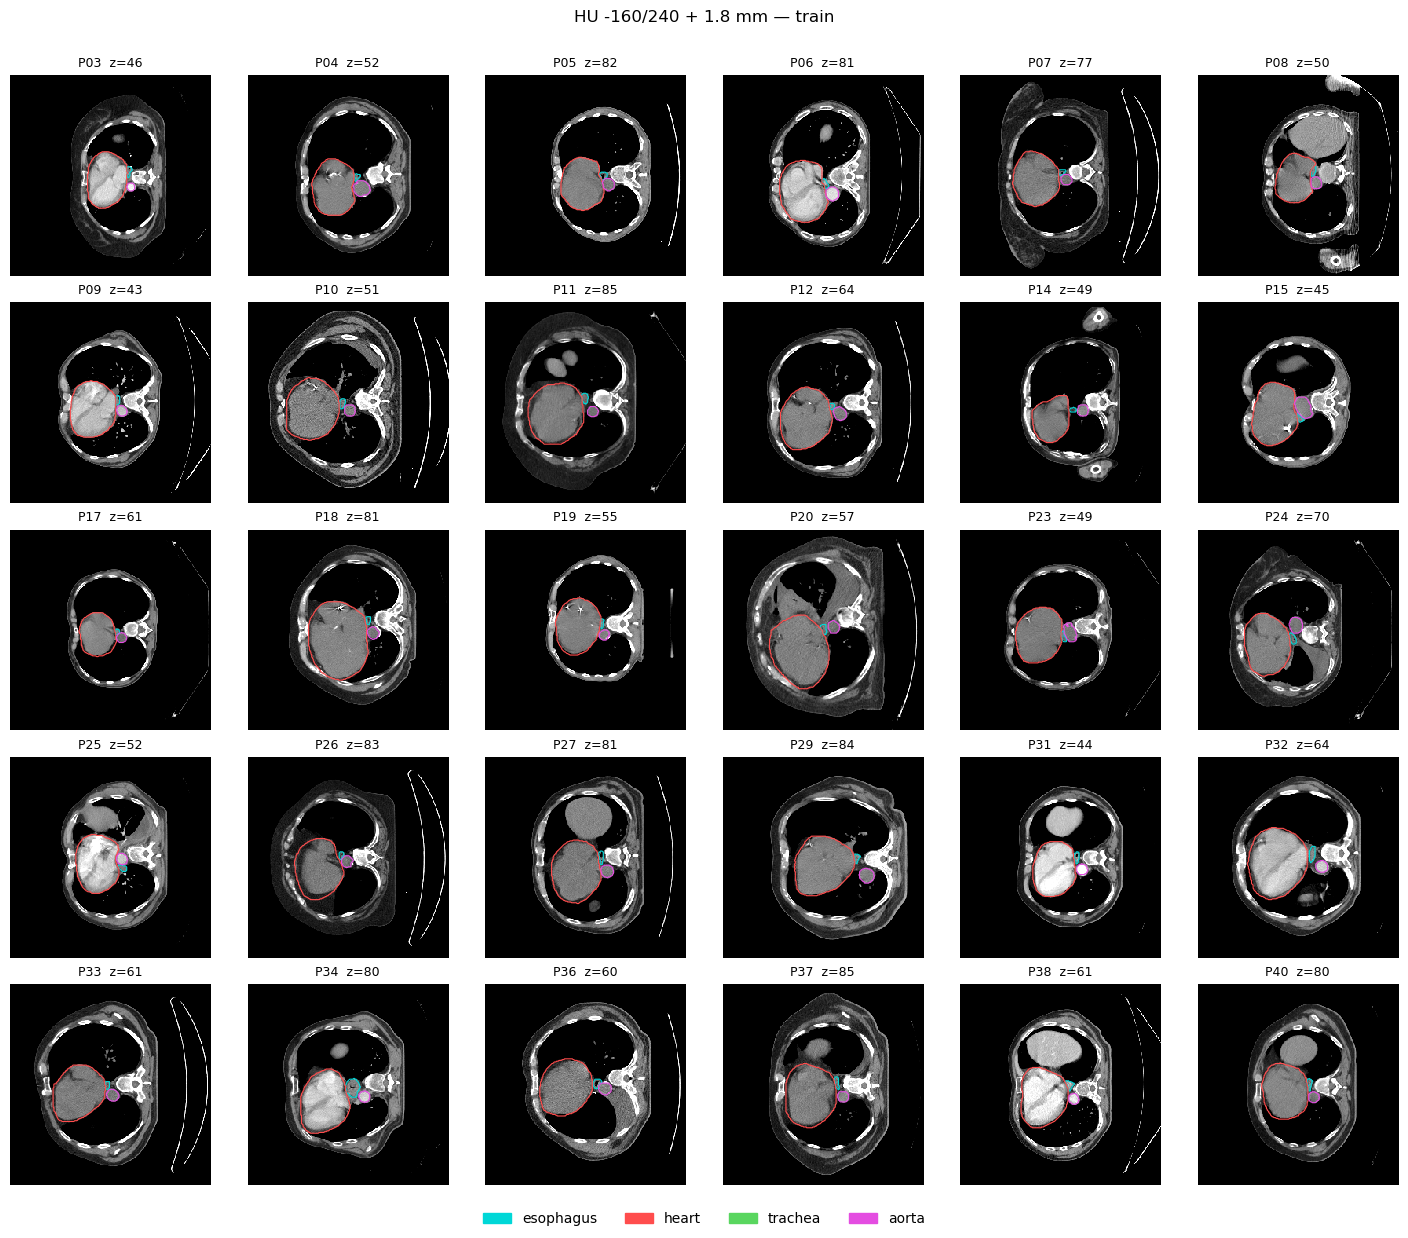

In [ ]:
GALLERY_OPTION = list(paths)[-1]  
COLS = 6

root = paths[GALLERY_OPTION]
gdf = scans[GALLERY_OPTION]["df"].copy()
gdf["fg"] = gdf[[LABEL_NAMES[k] for k in range(1, 5)]].sum(axis=1)
best = gdf.loc[gdf.groupby("patient")["fg"].idxmax()].sort_values("patient")

rows_n = int(np.ceil(len(best) / COLS))
fig, axes = plt.subplots(rows_n, COLS, figsize=(2.4 * COLS, 2.5 * rows_n), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, (_, row) in zip(axes.ravel(), best.iterrows()):
    img, gt = load_pair(root, SPLIT, row["file"])
    show(ax, img, gt, title=f"{row['patient'].replace('Patient_', 'P')}  z={row['z']}")
fig.legend(handles=LEGEND, loc="lower center", ncol=4, frameon=False)
fig.suptitle(f"{GALLERY_OPTION} — {SPLIT}", fontsize=12)
height = fig.get_figheight()
fig.tight_layout(rect=(0, 0.35 / height, 1, 1 - 0.3 / height))
plt.show()

## 7. Normalization statistics per option

Mean and std of the `SPLIT` images after dividing by 255, i.e. `compute_norm_stats.py` output

In [9]:
rows = []
for name, s in scans.items():
    st = hist_stats(s["hist_all"])
    rows.append({"option": name, "mean (x/255)": st["mean"] / 255, "std (x/255)": st["std"] / 255,
                 "% pixels at 0": 100 * s["hist_all"][0] / s["hist_all"].sum(),
                 "% pixels at 255": 100 * s["hist_all"][255] / s["hist_all"].sum()})
display(pd.DataFrame(rows).set_index("option").round(4))

,mean (x/255),std (x/255),% pixels at 0,% pixels at 255
option,,,,
baseline (min-max),0.0457,0.0884,55.7333,0.0006
percentile 1-99,0.2058,0.3193,36.0393,0.5777
HU -1000/400,0.1904,0.2960,36.4582,0.3543
HU -250/350,0.0973,0.1986,76.4993,0.4450
HU -160/240,0.0927,0.2051,76.9864,0.7826
HU -160/240 + 1.8 mm,0.1122,0.2233,72.8479,1.5141
